# Baseline Segmentation

**Objective:**
Create a simple baseline segmentation model to serve as a reference point for more sophisticated clustering approaches. Before modeling, we must preprocess the skewed RFM features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## 1. Load RFM Data & Preprocessing
As observed in Phase 5, Frequency and Monetary are highly right-skewed. K-Means is extremely sensitive to variance and outliers. We will apply a Log Transformation followed by Standardization (Z-score scaling).

In [2]:
rfm = pd.read_csv('../data/processed/rfm_features.csv')
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Handle zero or negative values for log transformation
def handle_zero_neg(x):
    if x <= 0:
        return 1
    else:
        return x

rfm_log = rfm_features.copy()
rfm_log['Recency'] = rfm_log['Recency'].apply(handle_zero_neg)
rfm_log['Frequency'] = rfm_log['Frequency'].apply(handle_zero_neg)
rfm_log['Monetary'] = rfm_log['Monetary'].apply(handle_zero_neg)

# Log transform
rfm_log = np.log(rfm_log)

# Scale data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns)
print("Preprocessing Complete: Log Transformation + Standard Scaling")

Preprocessing Complete: Log Transformation + Standard Scaling


## 2. Baseline Model: K-Means (K=3)
We select K-Means with `K=3` (e.g., representing High, Medium, and Low-value customers) as our simple, interpretable baseline.

In [3]:
# Set random state for reproducibility
kmeans_baseline = KMeans(n_clusters=3, random_state=42, n_init=10)
baseline_labels = kmeans_baseline.fit_predict(rfm_scaled)

rfm['Baseline_Cluster'] = baseline_labels
rfm_scaled_df['Baseline_Cluster'] = baseline_labels

## 3. Evaluation of Baseline
We evaluate the baseline using the **Silhouette Score** (measuring how similar an object is to its own cluster compared to others).

In [4]:
sil_score = silhouette_score(rfm_scaled, baseline_labels)
print(f"Baseline K-Means (K=3) Silhouette Score: {sil_score:.4f}")

Baseline K-Means (K=3) Silhouette Score: 0.3398


## 4. Visualizing the Baseline Clusters
We visualize the clusters in a 2D space using a scatter plot of Recency vs. Monetary (Log Scaled).

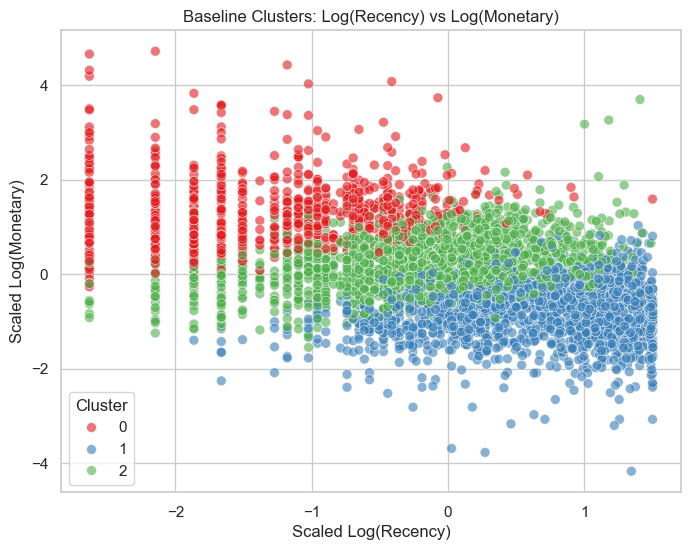

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=rfm_scaled_df['Recency'], y=rfm_scaled_df['Monetary'], 
                hue=rfm_scaled_df['Baseline_Cluster'], palette='Set1', s=50, alpha=0.6)
plt.title('Baseline Clusters: Log(Recency) vs Log(Monetary)')
plt.xlabel('Scaled Log(Recency)')
plt.ylabel('Scaled Log(Monetary)')
plt.legend(title='Cluster')
plt.savefig('../reports/figures/baseline_clusters.png', dpi=300)
plt.show()

## 5. Baseline Evaluation Summary

### Why this is the baseline
K-Means with K=3 provides a universally understood, fast, and highly interpretable "High / Medium / Low" grouping. 

### Assumptions
* Assumes spherical clusters with similar variance.
* Assumes every data point belongs strictly to one cluster.

### Strengths
* Simple to understand and explain to business stakeholders.
* Computationally very fast.

### Weaknesses
* Arbitrarily choosing K=3 might force unnatural groupings.
* Highly sensitive to the shape of the data (struggles with non-spherical clusters).

### Next Steps
In Phase 7, we will explore optimal K-selection methods and alternative clustering algorithms like Agglomerative Clustering and DBSCAN to see if they can achieve better separation or more meaningful business segments.

## 6. Alternative Method 1: K-Means (Optimal K Search)

### How it works & Rationale
K-Means partitions data into K distinct clusters based on distance to the centroid. It suits this problem well because RFM data (once scaled) tends to group into high/medium/low tiers naturally. 

### Assumptions
* Clusters are convex and isotropic (spherical).
* Similar variance across clusters.

### Hyperparameters
* `n_clusters` (K). We will find this using the Elbow Method and Silhouette Score.

### Advantages & Limitations
* **Advantages**: Fast, scales well, highly interpretable.
* **Limitations**: Requires predefined K, sensitive to outliers (handled via our log-transform).

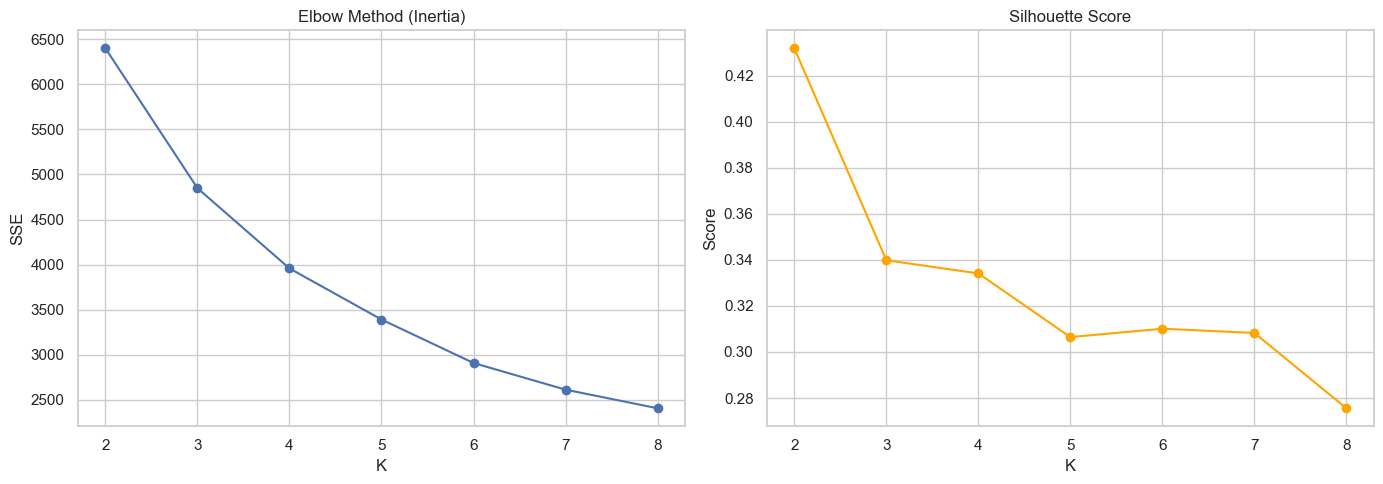

In [6]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

sse = {}
silhouette_scores = {}

# Test K from 2 to 8
for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    sse[k] = kmeans.inertia_
    silhouette_scores[k] = silhouette_score(rfm_scaled, labels)

# Plotting the metrics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(sse.keys()), list(sse.values()), marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('SSE')

axes[1].plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', color='orange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('../reports/figures/kmeans_evaluation.png', dpi=300)
plt.show()

Based on the graphs, the Silhouette score peaks strongly at **K=2** (likely separating 'purchased once' vs 'purchased multiple times'). However, business-wise, 2 segments is often too broad. The score drops at K=3, but K=4 often provides a good balance in RFM. Let's select **K=4** for our optimal K-Means as it offers better business granularity than K=2 while maintaining a reasonable elbow bend.

In [7]:
optimal_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = optimal_kmeans.fit_predict(rfm_scaled)
rfm['KMeans_Cluster'] = kmeans_labels

print("K-Means (K=4) Metrics:")
print(f"Silhouette: {silhouette_score(rfm_scaled, kmeans_labels):.4f}")
print(f"Calinski-Harabasz: {calinski_harabasz_score(rfm_scaled, kmeans_labels):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(rfm_scaled, kmeans_labels):.4f}")

K-Means (K=4) Metrics:


Silhouette: 0.3341
Calinski-Harabasz: 3306.1490
Davies-Bouldin: 1.0165


## 7. Alternative Method 2: Agglomerative (Hierarchical) Clustering

### How it works & Rationale
Builds a hierarchy of clusters using a bottom-up approach. It is useful here because it doesn't strictly assume spherical clusters and allows us to visualize the merging process via a dendrogram.

### Assumptions
* Choice of linkage (Ward minimizes variance within clusters).

### Hyperparameters
* `n_clusters` = 4 (for direct comparison to K-Means).
* `linkage` = 'ward'.

### Advantages & Limitations
* **Advantages**: No need to pre-specify K if using distance thresholds, produces a hierarchy.
* **Limitations**: Computationally expensive for large datasets ($O(N^3)$ or $O(N^2)$), making it slow for 4,000+ points compared to K-Means.

In [8]:
from sklearn.cluster import AgglomerativeClustering

agg_cluster = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels = agg_cluster.fit_predict(rfm_scaled)
rfm['Agg_Cluster'] = agg_labels

print("Agglomerative (K=4) Metrics:")
print(f"Silhouette: {silhouette_score(rfm_scaled, agg_labels):.4f}")
print(f"Calinski-Harabasz: {calinski_harabasz_score(rfm_scaled, agg_labels):.4f}")
print(f"Davies-Bouldin: {davies_bouldin_score(rfm_scaled, agg_labels):.4f}")

Agglomerative (K=4) Metrics:


Silhouette: 0.2352
Calinski-Harabasz: 2743.2382
Davies-Bouldin: 1.2831


## 8. Alternative Method 3: DBSCAN

### How it works & Rationale
Density-Based Spatial Clustering of Applications with Noise groups together closely packed points and marks outliers as noise. Great for non-spherical data.

### Assumptions
* Clusters are dense regions separated by sparse regions.

### Hyperparameters
* `eps`: Maximum distance between two samples to be considered in the same neighborhood.
* `min_samples`: Number of samples in a neighborhood for a point to be a core point.

### Advantages & Limitations
* **Advantages**: Discovers arbitrary shapes, robust to outliers (marks them as -1).
* **Limitations**: Extremely sensitive to `eps` and `min_samples`. Struggles with varying density clusters.

In [9]:
from sklearn.cluster import DBSCAN

# We use relatively broad eps and min_samples since RFM scaled data can be dense in the center
dbscan = DBSCAN(eps=0.5, min_samples=10)
db_labels = dbscan.fit_predict(rfm_scaled)
rfm['DBSCAN_Cluster'] = db_labels

# Filter out noise (-1) for metric evaluation if there are multiple valid clusters
n_clusters_ = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_ = list(db_labels).count(-1)

print(f"DBSCAN found {n_clusters_} clusters and {n_noise_} noise points.")

if n_clusters_ > 1:
    print("DBSCAN Metrics (including noise as a cluster):")
    print(f"Silhouette: {silhouette_score(rfm_scaled, db_labels):.4f}")
else:
    print("Not enough clusters found by DBSCAN to calculate meaningful metrics.")

DBSCAN found 2 clusters and 77 noise points.
DBSCAN Metrics (including noise as a cluster):


Silhouette: 0.2997
